# Atividade Prática — Aula 1  
## Python para Análise de Dados: do dado bruto à decisão estratégica

Nesta atividade, você vai aplicar os conceitos apresentados na aula usando um dataset simulado de vendas no varejo brasileiro.

**Arquivo de dados:** `vendas_brasil_aula1.csv`  
**Objetivo:** praticar leitura de dados, inspeção inicial, qualidade dos dados, KPIs e escolha de visualizações.

---
### O que você vai treinar
- Entender o pipeline básico de análise
- Inspecionar um dataset com `pandas`
- Identificar problemas de qualidade de dados
- Definir KPIs de negócio
- Escolher gráficos adequados para responder perguntas do gestor

## Instruções
1. Faça upload do arquivo `vendas_brasil_aula1.csv` no Google Colab ou deixe-o na mesma pasta do notebook.
2. Execute as células na ordem.
3. Responda às perguntas **no próprio notebook**, em células de texto ou código.
4. Sempre que possível, explique **o que o resultado significa para o negócio**.

## Dataset utilizado

O arquivo contém registros de vendas com as seguintes colunas:

- `Data_Venda`: data da venda
- `Canal_Venda`: canal comercial
- `UF`: estado da venda
- `Produto`: produto vendido
- `Preco_Unitario`: preço unitário
- `Quantidade`: quantidade vendida
- `Custo_Unitario`: custo unitário do item
- `Receita`: valor total da venda
- `Lucro`: lucro total da venda

> Atenção: o dataset foi preparado com **alguns problemas de qualidade propositalmente**, para que você pratique inspeção e limpeza.

## 1) Preparação do ambiente
Execute a célula abaixo para importar a biblioteca principal da atividade.

In [1]:
import pandas as pd

## 2) Leitura do arquivo
Altere o caminho do arquivo, se necessário.

In [2]:
df = pd.read_csv("vendas_brasil_aula1.csv")
df.head()

,Data_Venda,Canal_Venda,UF,Produto,Preco_Unitario,Quantidade,Custo_Unitario,Receita,Lucro
0,2025-04-13,Loja Física,SP,Smartphone,2484.58,3,1872.49,7453.74,1836.27
1,2025-06-29,Loja Física,RJ,Smartwatch,1041.91,1,699.66,1041.91,342.25
2,2025-04-03,E-commerce,RJ,Smartphone,2447.07,1,2077.09,2447.07,369.98
3,2025-01-15,Loja Física,MG,Smartphone,2307.40,1,1797.67,2307.40,509.73
4,2025-04-17,E-commerce,PR,Notebook,3840.18,4,3069.45,15360.72,3082.92


## 3) Atividade 1 — Entendendo o dataset

Responda às perguntas abaixo usando código:

1. Quantas linhas e colunas existem no dataset?
2. Quais são os nomes das colunas?
3. Quais são os tipos de dados de cada coluna?

> Dica: use `shape`, `columns` e `info()`.

In [5]:
print(f"1. Tem{df.shape[0]} linhas e {df.shape[1]} colunas.")
print("2. Nomes das colunas:")
for col in df.columns:
    print(f"{col}")
print("3. Tipos de dados:")
df.info()

1. Tem300 linhas e 9 colunas.
2. Nomes das colunas:
Data_Venda
Canal_Venda
UF
Produto
Preco_Unitario
Quantidade
Custo_Unitario
Receita
Lucro
3. Tipos de dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Data_Venda      300 non-null    object 
 1   Canal_Venda     293 non-null    object 
 2   UF              294 non-null    object 
 3   Produto         300 non-null    object 
 4   Preco_Unitario  295 non-null    float64
 5   Quantidade      300 non-null    int64  
 6   Custo_Unitario  300 non-null    float64
 7   Receita         300 non-null    float64
 8   Lucro           300 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 21.2+ KB


## 4) Atividade 2 — Qualidade dos dados

Agora investigue se existem problemas de qualidade.

Responda:

1. Existem valores nulos?
2. Em quais colunas eles aparecem?
3. Existem categorias escritas de formas diferentes para o mesmo canal de venda?

> Dica: use `isnull().sum()` e `value_counts()`.

In [25]:
print("Sim, tem valores nulos")
print('')

print('Valores Nulos por Coluna')
df.isnull().sum()


Sim, tem valores nulos

Valores Nulos por Coluna

Categorias em Canal_Venda


,count
Canal_Venda,
E-Commerce,107
Loja Física,99
Marketplace,42
Whatsapp,37
Loja Fisica,8
Não Informado,7


In [26]:
print('\nCategorias em Canal_Venda')
df['Canal_Venda'].value_counts()


Categorias em Canal_Venda


,count
Canal_Venda,
E-Commerce,107
Loja Física,99
Marketplace,42
Whatsapp,37
Loja Fisica,8
Não Informado,7


## 5) Atividade 3 — KPIs do negócio

Considere que você é analista de um varejista e precisa apresentar indicadores para a gestão.

Calcule os seguintes KPIs:

1. **Receita total**
2. **Lucro total**
3. **Ticket médio** (`Receita média por registro`)
4. **Quantidade total vendida**

Depois, escreva uma breve interpretação:
- O desempenho geral parece positivo?
- Receita e lucro caminham juntos?

In [27]:
receita_total = df['Receita'].sum()

lucro_total = df['Lucro'].sum()

ticket_medio = df['Receita'].mean()

quantidade_total = df['Quantidade'].sum()

print(f'Receita Total: R$ {receita_total:,.2f}')
print(f'Lucro Total: R$ {lucro_total:,.2f}')
print(f'Ticket Médio: R$ {ticket_medio:,.2f}')
print(f'Quantidade Total: {quantidade_total} unidades')

# O desempenho geral parece bom
# A receita e o lucro caminham juntos sim

Receita Total: R$ 707,535.36
Lucro Total: R$ 189,625.88
Ticket Médio: R$ 2,358.45
Quantidade Total: 502 unidades


## 6) Atividade 4 — Respondendo perguntas do gestor com dados

Use o dataset para responder:

1. **Qual canal gera mais receita?**
2. **Qual produto gera mais lucro?**
3. **Quais UFs concentram maior receita?**

In [32]:
import pandas as pd

# 1. Qual canal gera mais receita?
receita_por_canal = df.groupby('Canal_Venda')['Receita'].sum().sort_values(ascending=False)
print(receita_por_canal)
print("\nO canal 'Loja Física' lidera em faturamento")

# 2. Qual produto gera mais lucro?
lucro_por_produto = df.groupby('Produto')['Lucro'].sum().sort_values(ascending=False)
print(lucro_por_produto)
print("\nO 'Notebook' é o produto mais lucrativo")

# 3. Quais UFs concentram maior receita?
receita_por_uf = df.groupby('UF')['Receita'].sum().sort_values(ascending=False)
print(receita_por_uf)
print("\nSP e RJ")

Canal_Venda
E-Commerce       249338.01
Loja Física      216644.15
Marketplace      111659.78
Whatsapp          85974.51
Não Informado     24917.75
Loja Fisica       19001.16
Name: Receita, dtype: float64

O canal 'Loja Física' lidera em faturamento
Produto
Notebook            69818.57
Smartphone          31718.11
Tablet              20936.95
Monitor             18290.52
Smartwatch          17029.45
Teclado Mecânico    12859.48
Fone Bluetooth      11647.92
Mouse Gamer          7324.88
Name: Lucro, dtype: float64

O 'Notebook' é o produto mais lucrativo
UF
SP               133727.80
MG               103438.61
RJ               100284.68
PR                69287.74
SC                63740.20
RS                51020.06
ES                50338.64
BA                46765.01
PE                42895.39
GO                25179.98
Não Informado     20857.25
Name: Receita, dtype: float64

SP e RJ


## 7) Atividade 5 — Escolhendo a visualização certa

Sem necessariamente construir os gráficos ainda, responda:

a) Qual gráfico você usaria para mostrar a **evolução da receita ao longo do tempo**?  
b) Qual gráfico você usaria para **comparar a receita entre canais de venda**?  
c) Qual gráfico você usaria para mostrar a **distribuição dos preços unitários**?

Em seguida, gere **ao menos um gráfico** com `pandas` ou `matplotlib`.

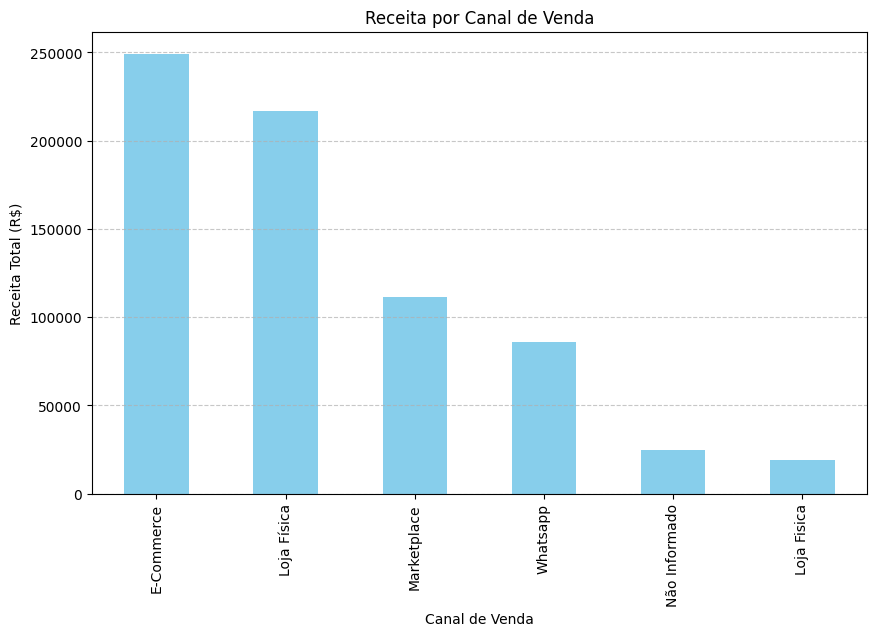

In [34]:
# a) Evolução da receita ao longo do tempo: Gráfico de Linhas.
# b) Comparar receita entre canais: Gráfico de Barras.
# c) Distribuição de preços unitários: Histograma.

ax = receita_por_canal.plot(kind='bar',
                            figsize=(10, 6),
                            color='skyblue',
                            title='Receita por Canal de Venda')

ax.set_xlabel('Canal de Venda')
ax.set_ylabel('Receita Total (R$)')
ax.grid(axis='y', linestyle='--', alpha=0.7)

## Desafio extra (opcional)

Faça uma pequena limpeza no dataset:

- trate valores nulos;
- padronize os nomes dos canais de venda;
- converta `Data_Venda` para formato de data.

Depois, compare os resultados **antes e depois da limpeza**.

## Desafio Extra: Limpeza de Dados

### Subtask:
Tratar valores nulos, padronizar strings da coluna 'Canal_Venda' e converter 'Data_Venda' para o formato datetime, comparando os dados antes e depois.


In [41]:
import pandas as pd

# 1. Cópia para comparação
df_antes = df.copy()

# 2. Padronização de Canal_Venda
# Convertendo para Title Case e removendo espaços extras
df['Canal_Venda'] = df['Canal_Venda'].str.strip().str.title()
# Ajustando o 'E-Commerce' para manter o hífen padrão se necessário, mas Title já ajuda muito

# 3. Conversão de Data_Venda
df['Data_Venda'] = pd.to_datetime(df['Data_Venda'])

# 4. Comparação Antes vs Depois
print("--- Nulos ANTES ---")
print(df_antes.isnull().sum())
print("\n--- Nulos DEPOIS ---")
print(df.isnull().sum())

print("\n--- Categorias Canal_Venda ANTES ---")
print(df_antes['Canal_Venda'].value_counts(dropna=False))

print("\n--- Categorias Canal_Venda DEPOIS ---")
print(df['Canal_Venda'].value_counts())

print(f"\nTipo da coluna Data_Venda agora: {df['Data_Venda'].dtype}")

--- Nulos ANTES ---
Data_Venda        0
Canal_Venda       0
UF                0
Produto           0
Preco_Unitario    0
Quantidade        0
Custo_Unitario    0
Receita           0
Lucro             0
dtype: int64

--- Nulos DEPOIS ---
Data_Venda        0
Canal_Venda       0
UF                0
Produto           0
Preco_Unitario    0
Quantidade        0
Custo_Unitario    0
Receita           0
Lucro             0
dtype: int64

--- Categorias Canal_Venda ANTES ---
Canal_Venda
Loja Física      107
E-Commerce       107
Marketplace       42
Whatsapp          37
Não Informado      7
Name: count, dtype: int64

--- Categorias Canal_Venda DEPOIS ---
Canal_Venda
Loja Física      107
E-Commerce       107
Marketplace       42
Whatsapp          37
Não Informado      7
Name: count, dtype: int64

Tipo da coluna Data_Venda agora: datetime64[ns]
